## Remote Head-direction Testbed

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_angle_animal
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, Imu

[2026-03-09 12:37:47,982][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[12:38:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:38:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:38:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:38:02][WARNING] Spyglass: Deprecation: this class has b

In [4]:
from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.helpers import interpolate_to_new_time

In [5]:
from spyglass.shijiegu.gyroscope import load_tracking_result, load_tracking_data_position

In [6]:
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd

In [29]:
output_folder = '/stelmo/shijie/gyro/'
nwb_file_name = "julio20230731.nwb"
session_name = "04_Seq2Session2"
trial = 12


In [30]:
### Get result from TrodesTrack
pos_info_ssm = load_tracking_result(output_folder, nwb_file_name, session_name, trial)

### Get result from IntervalPosition
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
position_name = session2position_name(nwb_copy_file_name, session_name)
pos_info_2d_session = (IntervalPositionInfo() & {
    'nwb_file_name':nwb_copy_file_name,
    'interval_list_name':position_name,
    'position_info_param_name':'default_decoding'}).fetch1_dataframe()

[2025-12-17 14:45:01,318][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2025-12-17 14:45:01,330][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2025-12-17 14:45:01,341][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2025-12-17 14:45:01,349][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb


In [31]:
### Select data from IntervalPosition
(t0,t1) = (pos_info_ssm.index[0], pos_info_ssm.index[-1]) 
pos_info_2d = select_subset_helper_pd(pos_info_2d_session,(t0,t1))
pos_info_2d_subset = interpolate_to_new_time(pos_info_2d, pos_info_ssm.index)

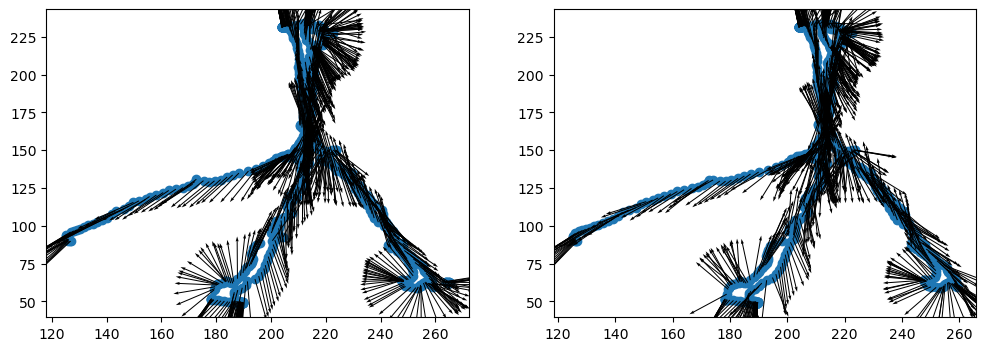

In [32]:
quiver_scale = 10
fig, axes = plt.subplots(1,2,figsize = (12,4))
axes[0].scatter(pos_info_ssm.head_position_x, pos_info_ssm.head_position_y)
axes[0].quiver(pos_info_ssm.head_position_x, pos_info_ssm.head_position_y, 
               np.cos(pos_info_ssm.head_orientation), np.sin(pos_info_ssm.head_orientation), scale = quiver_scale)
axes[1].scatter(pos_info_2d_subset.head_position_x, pos_info_2d_subset.head_position_y)
axes[1].quiver(pos_info_2d_subset.head_position_x, pos_info_2d_subset.head_position_y, 
               np.cos(pos_info_2d_subset.head_orientation), np.sin(pos_info_2d_subset.head_orientation), scale = quiver_scale)


### Load frames

In [33]:
from spyglass.shijiegu.video import load_video_and_timestamps, make_mp4
from trodestrack.data.visualize_filter_overlay_fast import create_filter_overlay_video_fast
from spyglass.shijiegu.video import increase_brightness
import cv2

In [34]:
cap, timestamps, meters_per_pixel = load_video_and_timestamps(nwb_copy_file_name, session_name)

In [36]:
frameToPlot = np.argwhere(np.logical_and(timestamps>=t0,timestamps<=t1)).ravel()
frame0 = frameToPlot[0]
frameLast = frameToPlot[-1]

fps = cap.get(cv2.CAP_PROP_FPS) # Gets the frames per second
frameSize = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

frames = []
for fi in range(len(timestamps)):##len(frameToPlot)):
    t = timestamps[fi]

    ret, frame = cap.read()
    frameBrighter = increase_brightness(frame)
    if fi >= frame0 and fi <= frameLast:
        frames.append(frame)
    if fi > frameLast:
        break

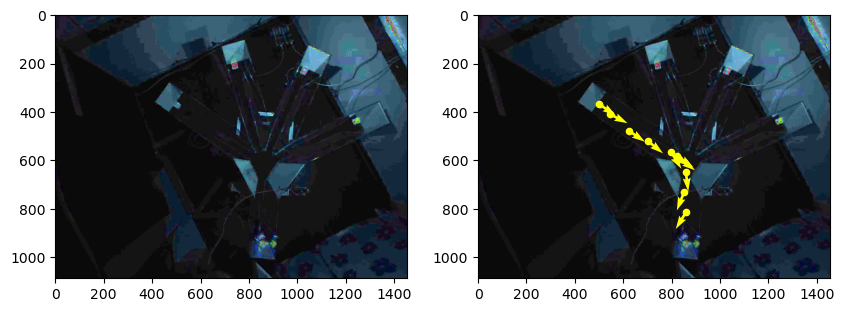

In [14]:
pixel_per_cm = 0.25
arrow_length = 100

fig, axes = plt.subplots(1,2,figsize = (10,8))

ind = 10
axes[0].imshow(frames[ind]*10)

axes[1].imshow(frames[ind]*10)

for ind in range(1300,1400,10):
    (x, y) = (np.array(pos_info_ssm.head_position_x)[ind], np.array(pos_info_ssm.head_position_y)[ind])
    axes[1].scatter(x/pixel_per_cm,
                    y/pixel_per_cm, color = 'yellow', s = 20)
    
    arrow_heading = np.array(pos_info_ssm.head_orientation) + np.pi
    dx = arrow_length * np.cos(arrow_heading)[ind]
    dy = arrow_length * np.sin(arrow_heading)[ind]
    axes[1].quiver(x/pixel_per_cm,y/pixel_per_cm, dx, dy, linewidth = 5, color = 'yellow', angles = 'xy')


### Make video

In [ ]:
#outputName = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trialID}'
outputName = f'position_{nwb_file_name}_{session_name}_trial{trial}'
make_mp4(cap, timestamps, t0, t1, outputName)

In [ ]:
# data
file_path = os.path.join(output_folder,f'tracking_{nwb_file_name}_{session_name}_trial{trial}_result.pkl')#with open(imu_path, 'rb') as file:
with open(file_path, 'rb') as file:
    packed_data = pickle.load(file)
input_data = packed_data["packed_data"]

file_path = os.path.join(output_folder,f'tracking_{nwb_file_name}_{session_name}_trial{trial}_result.pkl')
with open(file_path, 'rb') as file:
    result = pickle.load(file)
       
result = result["result"] 

spatial_subset_df = load_tracking_data_position(output_folder, nwb_file_name, session_name, trial)

In [ ]:
create_filter_overlay_video_fast(
    video_path = outputName + '_rawposition.mp4',
    data = input_data,
    filter_result = result,
    t_filter = input_data.t_cam,
    position_df = spatial_subset_df,
    output_path = f"filter_{nwb_file_name}_{session_name}.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0
)

### Test the whole angle calculation pipeline

In [7]:
list_of_days_animals, encoding_set_animals, classifier_param_name_animals = {}, {}, {}

In [8]:
animal = "julio"
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [12]:
animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [13]:
animal = "molly"
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [25]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMindRemoteTheta

In [29]:
ChangeofMindRemoteTheta() & {'nwb_file_name': 'julio20230731_.nwb', 'epoch': 2}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),proportion minimal amount of proportion the animal is in before it backed out,parameter parameter name,"remote_parameter time in seconds, the min duration of an event","pandas pandas dataframe saved as dictionary, choice"
julio20230731_.nwb,2,0.1,params_both_max_all_maze_2_state,dur_0.02_sum_0.2,=BLOB=
julio20230731_.nwb,2,0.1,params_both_max_run_time_2_state,dur_0.02_sum_0.2,=BLOB=
julio20230731_.nwb,2,0.1,params_both_max_run_time_2_state,dur_0.02_sum_0.4,=BLOB=


In [47]:
angles_animals = {}

theta_params = "params_both_max_run_time_2_state"
classifier_param_name = None

for animal in ["klein","molly"]:
    list_of_days = list_of_days_animals[animal]
    encoding_set = encoding_set_animals[animal]
    classifier_param_name = classifier_param_name_animals[animal]
    proportion = 0.1
    
    angles_animals[animal], v1, v2, max_posterior_2d, head_orientation, animal_location = find_angle_animal(
                        animal, list_of_days, list_of_days,
                        theta_params,
                        encoding_set,
                        classifier_param_name, proportion,
                        debug = False, use_gyro = True, imu_param_name = "big_acc_bias")

Loading from spyglass database instead of pickle file.
klein20231101_.nwb
klein20231102_.nwb
klein20231103_.nwb
klein20231104_.nwb
klein20231105_.nwb
No triggered decode found for  {'nwb_file_name': 'klein20231105_.nwb', 'epoch': 8, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
klein20231106_.nwb
klein20231107_.nwb
klein20231108_.nwb
some missing position data
{'nwb_file_name': 'klein20231102_.nwb', 'epoch': '04', 'trial': 15, 'parameter': 'big_acc_bias'}
{'nwb_file_name': 'klein20231102_.nwb', 'epoch': '04', 'trial': 28, 'parameter': 'big_acc_bias'}
{'nwb_file_name': 'klein20231102_.nwb', 'epoch': '10', 'trial': 10, 'parameter': 'big_acc_bias'}
{'nwb_file_name': 'klein20231103_.nwb', 'epoch': '02', 'trial': 42, 'parameter': 'big_acc_bias'}
{'nwb_file_name': 'klein20231103_.nwb', 'epoch': '04', 'trial': 5, 'parameter': 'big_acc_bias'}
{'nwb_file_name': 'klein20231103_.nwb', 'epoch': '04', 'trial': 7

In [44]:
#angles_animals[animal]

In [45]:
#%debug

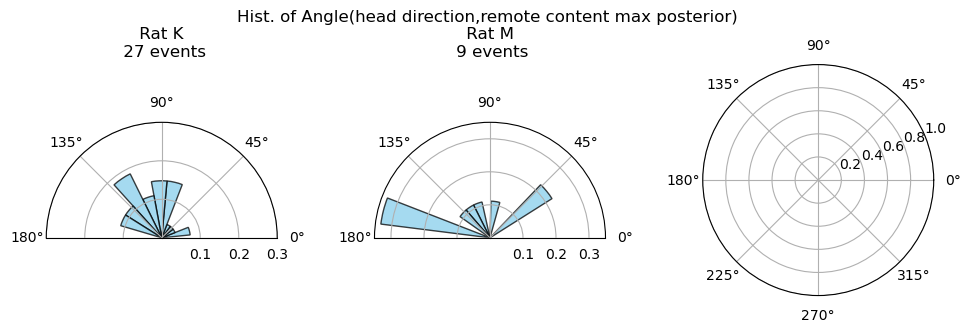

In [49]:
# Create a figure and a polar subplot
fig, axes = plt.subplots(1,3, figsize = (12,3), subplot_kw={'projection': 'polar'})

ind = 0
for animal in ["klein","molly"]:
    angles = angles_animals[animal]
    n, bins, patches = axes[ind].hist(angles, weights = np.ones(len(angles))/len(angles),
                                      bins=10, alpha=0.75, color='skyblue', edgecolor='black')

    # Set the title
    if ind == 1:
        axes[ind].set_title(f'Hist. of Angle(head direction,remote content max posterior) \n Rat {animal[0].upper()} \n {len(angles)} events')
    else:
        axes[ind].set_title(f'\n Rat {animal[0].upper()} \n {len(angles)} events')
    axes[ind].set_thetamin(0)
    axes[ind].set_thetamax(180)
    axes[ind].set_rticks([0.1, 0.2, 0.3]) #
    
    ind += 1

plt.show()
# Display the plot

NameError: name 'frames' is not defined

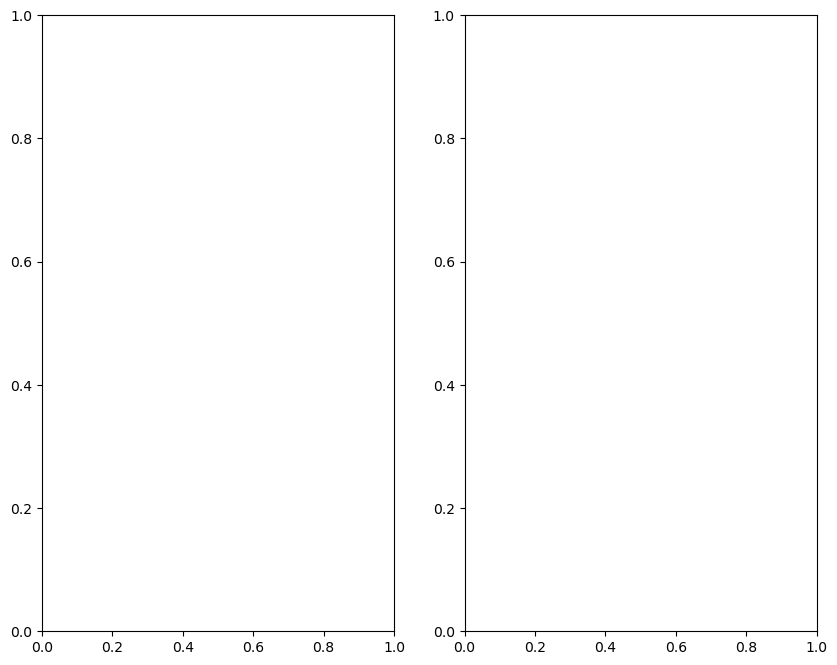

In [35]:
pixel_per_cm = 0.25
arrow_length = 100

fig, axes = plt.subplots(1,2,figsize = (10,8))

ind = 10
axes[0].imshow(frames[ind]*10)

axes[1].imshow(frames[ind]*10)

for ind in range(max_posterior_2d.shape[0]):
    (x, y) = max_posterior_2d[ind]
    axes[1].scatter(x/pixel_per_cm,
                    y/pixel_per_cm, color = 'yellow', s = 20)

    (x, y) = animal_location[ind]
    axes[1].scatter(x/pixel_per_cm,
                    y/pixel_per_cm, color = 'magenta', s = 20)


for f in range(v2.shape[0]):
    dx = arrow_length * v2[f][0]
    dy = arrow_length * v2[f][1]
    axes[1].quiver(x/pixel_per_cm,y/pixel_per_cm, dx, dy, linewidth = 5, color = 'yellow', angles = 'xy')


# animal head direction
arrow_heading = head_orientation[0]
dx = arrow_length * np.cos(arrow_heading)
dy = arrow_length * np.sin(arrow_heading)
axes[1].quiver(x/pixel_per_cm,y/pixel_per_cm, dx, dy, linewidth = 5, color = 'magenta', angles = 'xy')


arrow_heading = head_orientation[0] - angles[0]
dx = arrow_length * np.cos(arrow_heading)
dy = arrow_length * np.sin(arrow_heading)
axes[1].quiver(x/pixel_per_cm,y/pixel_per_cm, dx, dy, linewidth = 5, color = 'blue', angles = 'xy')
